# Breast Cancer Diagnosis: Regression, Regularization & Gradient Descent

**Week 2 — Building on Week 1**

Last week we explored the Wisconsin Breast Cancer dataset through two lenses: a closed-form
linear solver and a gradient descent linear classifier, both implemented from scratch so we
could see exactly what was happening inside `model.fit()`.

This week we move to the way practitioners actually build models: **scikit-learn**. The
algorithms are the same ones from the lecture slides.
implementations. We keep the **same preprocessing** as before, then walk through four ideas.

**The journey:**

| Step | What we do | Why |
|---|---|---|
| **1. Preprocessing** | Re-run the Week 1 pipeline | Establish the clean data we will model |
| **2. Polynomial Regression** | `LinearRegression` + `PolynomialFeatures` | See overfitting, then tame it with L1 / L2 |
| **3. Logistic Regression** | `SGDClassifier` (log-loss) | Fit a classifier by gradient descent |
| **4. Gradient Descent Variants** | Batch, Stochastic| Compare how different optimisers learn |
| **Take-home** | Two guided exercises | Practice what you learned |

---

## Setup: Imports & Loading the Data

Same dataset as Week 1. We also import everything we need upfront so it is easy to see which
library each tool comes from.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso,
    LogisticRegression, SGDClassifier
)
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, log_loss
)

In [ ]:
df = pd.read_csv("/content/dataset.csv", index_col=0)
df = df.drop('id', axis=1)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1: Preprocessing Pipeline (Week 1 Recap)

Same steps as Week 1, split, impute, scale, drop highly correlated features.

One change: labels are now **0 and 1** instead of -1 and 1. Scikit-learn's
`LogisticRegression` (and the binary cross entropy loss it minimises internally) expects this
convention.

In [ ]:
# Labels: 1 = Malignant, 0 = Benign
X = df.drop('diagnosis', axis=1)
y = (df['diagnosis'] == 'M').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X.select_dtypes(include='number').columns

# Imputing Outliers
for col in numeric_cols: # Iterate through each numeric column

  Q1 = X_train[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = X_train[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (X_train[col] < lower) | (X_train[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR

  if num_outliers > 0:
    median_val = X_train.loc[~outlier_mask, col].median() # Median computed from non-outlier values only, so the outliers themselves don't skew the value used to replace them
    X_train.loc[outlier_mask, col] = median_val # Replace each outlier with that column's median

    # apply the SAME train-fit bounds and value to test — no new stats from X_test
    test_outlier_mask = (X_test[col] < lower) | (X_test[col] > upper)
    X_test.loc[test_outlier_mask, col] = median_val


# Scale
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# Drop highly correlated features (same threshold as Week 1: r > 0.9)
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_train = X_train.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Dropped (high correlation): {to_drop}")

Training set : (455, 25)
Test set     : (114, 25)
Dropped (high correlation): ['perimeter_mean', 'area_mean', 'perimeter_se', 'radius_worst', 'perimeter_worst']


### Evaluation Helper

We will call this for every model variant, so let us define it once.

In [ ]:
results = {}   # we will fill this as we go

def evaluate(model_name, y_true, y_pred):

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"  {model_name}")
    print(f"  Accuracy  : {acc*100:.1f}%")
    print(f"  Precision : {prec:.3f}")
    print(f"  Recall    : {rec:.3f}")
    print(f"  F1 Score  : {f1:.3f}")

    cm   = confusion_matrix(y_true, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Malignant', 'Benign'])
    disp.plot(colorbar=False)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    results[model_name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1
    }

---

## 2: Polynomial Regression

### A quick experiment before we classify

Our real goal is to *classify* tumours, but first we run a small experiment with plain
**linear regression**. We treat the label as a number (1 = Malignant, 0 = Benign) and ask linear
regression to predict it. This is not how we would ship a diagnosis model, but it is the
cleanest way to *see* three very important ideas:

1. **Polynomial features** let a linear model bend, `PolynomialFeatures` adds squared terms
   (x₁²) and interaction terms (x₁·x₂).
2. **Overfitting**, a model that is too flexible memorises the training data and fails on new data.
3. **Regularization (L1 and L2)**, a penalty that keeps the weights small and the model honest.

We measure quality with Accuracy score :

>  Accuracy close to **100** = predictions match the targets.
> Accuracy score that is high on training data but **much lower on test data** = the model overfit.

### 2.1 Watching a model overfit

We try three levels of flexibility on the **same** data:

- **degree 1** — the plain linear model (25 features).
- **degree 2** — adds squares and pairwise products (25 → 350 features).
- **degree 3** — even more terms (25 → 3275 features), far more features than we have rows (455).

Watch the training Accuracy score climb toward 1.0 while the test Accuracy score falls apart. That gap *is* overfitting.

In [ ]:

degrees = [1, 2, 3]

train_accuracy_scores = []
test_accuracy_scores = []

print(f"{'Degree':>6} | {'# Features':>10} | {'Train Accuracy':>9} | {'Test Accuracy':>9}")
print("-" * 45)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Continuous predictions
    train_pred_prob = model.predict(X_train_poly)
    test_pred_prob = model.predict(X_test_poly)

    # Apply threshold
    train_pred = (train_pred_prob >= 0.5).astype(int)
    test_pred = (test_pred_prob >= 0.5).astype(int)

    train_accuracy = accuracy_score(y_train, train_pred)*100
    test_accuracy = accuracy_score(y_test, test_pred)*100

    train_accuracy_scores.append(train_accuracy)
    test_accuracy_scores.append(test_accuracy)

    print(
        f"{degree:>6} | {X_train_poly.shape[1]:>10} | "
        f"{train_accuracy:>9.1f}% | {test_accuracy:>9.1f}%"
    )

Degree | # Features | Train Accuracy | Test Accuracy
---------------------------------------------
     1 |         25 |      95.8% |      98.2%
     2 |        350 |     100.0% |      74.6%
     3 |       3275 |     100.0% |      75.4%


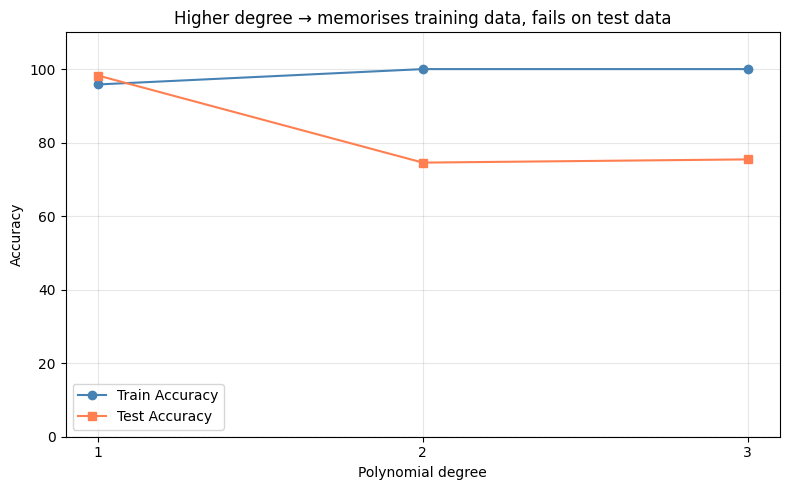

In [ ]:
# The same story as a picture
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_accuracy_scores, 'o-', color='steelblue', label='Train Accuracy')
plt.plot(degrees, test_accuracy_scores,  's-', color='coral',     label='Test Accuracy')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.ylim(0, 110)
plt.xticks(degrees)
plt.xlabel('Polynomial degree')
plt.ylabel('Accuracy')
plt.title('Higher degree → memorises training data, fails on test data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Fixing overfitting with regularization (L1 & L2)

Regularization adds a penalty for large weights to the loss the model minimises. Two flavours:

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty added | sum of **squared** weights | sum of **absolute** weights |
| scikit-learn class | `Ridge` | `Lasso` |
| Tuning knob | `alpha` (larger = more penalty) | `alpha` (larger = more penalty) |
| Effect on weights | shrinks them all toward 0 | drives some to **exactly 0** |
| Gives sparsity? | No | Yes |

We take the **degree-3** features (3275 of them — plenty of room to overfit) and compare plain
linear regression against Ridge and Lasso on the **same** features.

In [ ]:


# Build degree-3 features once and reuse them
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly3.fit_transform(X_train)
X_test_poly  = poly3.transform(X_test)

print(f"Degree-3 features: {X_train_poly.shape[1]}")

# Three models on the SAME features
lin_model   = LinearRegression().fit(X_train_poly, y_train)
ridge_model = Ridge(alpha=1e+04).fit(X_train_poly, y_train)
lasso_model = Lasso(alpha=0.023, max_iter=200).fit(X_train_poly, y_train)

print(f"\n{'Model':<22} | {'Train Accuracy':>9} | {'Test Accuracy':>9}")
print("-" * 46)

for name, model in [
    ('Linear (no penalty)', lin_model),
    ('Ridge (L2)', ridge_model),
    ('Lasso (L1)', lasso_model)
]:

    # Continuous predictions
    train_pred = model.predict(X_train_poly)
    test_pred  = model.predict(X_test_poly)

    # Convert to classes using threshold 0.5
    train_pred = (train_pred >= 0.5).astype(int)
    test_pred  = (test_pred >= 0.5).astype(int)

    tr = accuracy_score(y_train, train_pred)*100
    te = accuracy_score(y_test, test_pred)*100

    print(f"{name:<22} | {tr:>9.1f} | {te:>9.1f}")

Degree-3 features: 3275

Model                  | Train Accuracy | Test Accuracy
----------------------------------------------
Linear (no penalty)    |     100.0 |      75.4
Ridge (L2)             |      92.3 |      93.0
Lasso (L1)             |      97.4 |      94.7


### 2.3 How many weights did Lasso switch off?

The headline difference between L1 and L2: **Lasso sets some weights to exactly zero**, which
means it quietly performs *feature selection*. It decides some of the 3275 features only **some** are worth using. Ridge shrinks weights but keeps them all. Let's count and picture it.

Total features: 3275

Linear (no penalty)    zero weights:    0   (active: 3275)
Ridge  (L2)            zero weights:    0   (active: 3275)
Lasso  (L1)            zero weights: 3217   (active: 58)


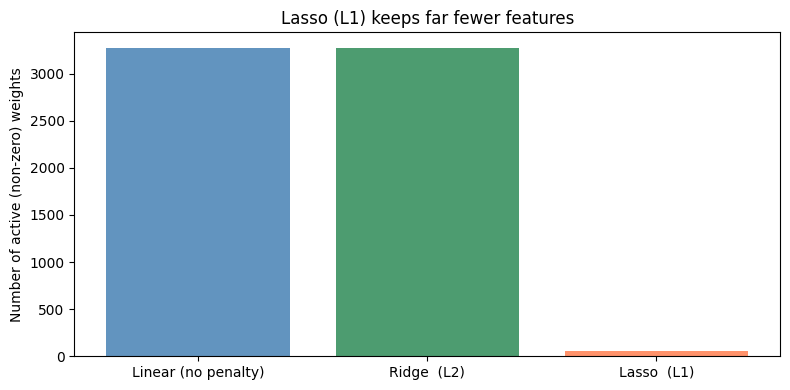

In [ ]:
'''Add a graph to show how ridge shrinks the weights, comparative'''

# Count how many coefficients are exactly zero in each model
n_features = X_train_poly.shape[1]
counts = {
    'Linear (no penalty)': int(np.sum(lin_model.coef_   == 0)),
    'Ridge  (L2)':         int(np.sum(ridge_model.coef_ == 0)),
    'Lasso  (L1)':         int(np.sum(lasso_model.coef_ == 0)),
}

print(f"Total features: {n_features}\n")
for name, zeros in counts.items():
    print(f"{name:<22} zero weights: {zeros:>4}   (active: {n_features - zeros})")

# Picture 1: how many weights stay ACTIVE (non-zero) in each model
plt.figure(figsize=(8, 4))
active = [n_features - z for z in counts.values()]
plt.bar(list(counts.keys()), active, color=['steelblue', 'seagreen', 'coral'], alpha=0.85)
plt.ylabel('Number of active (non-zero) weights')
plt.title('Lasso (L1) keeps far fewer features')
plt.tight_layout()
plt.show()



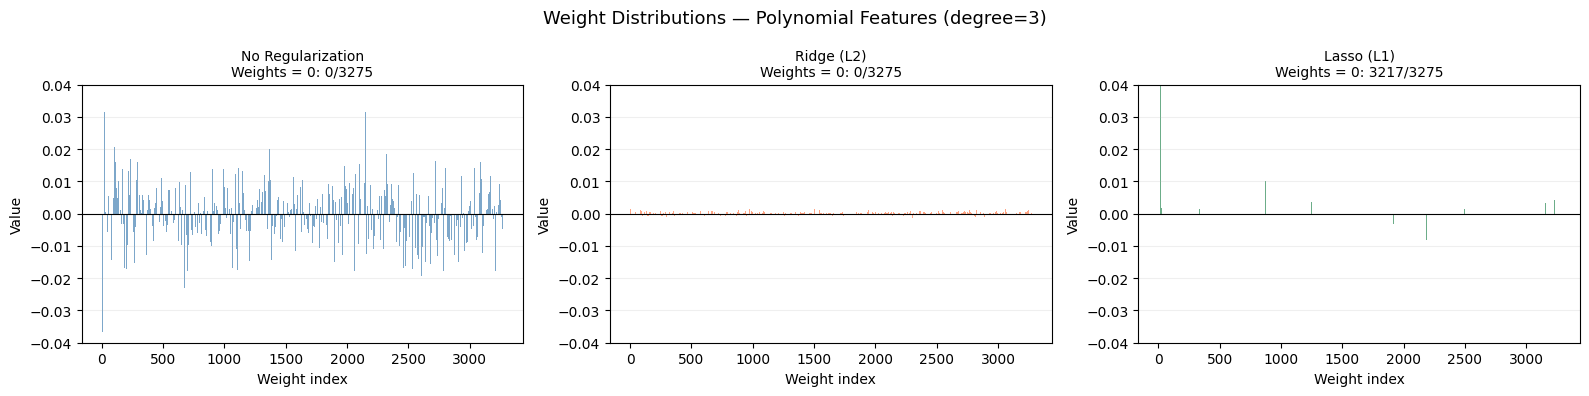

No reg : std = 0.0089
Ridge  : std = 0.0005  (shrunk, but none exactly 0)
Lasso  : std = 0.0045  (many exactly 0 -> sparse model)
Lasso  : 3217 of 3275 weights zeroed out


In [ ]:
w_noreg = lin_model.coef_
w_ridge = ridge_model.coef_
w_lasso = lasso_model.coef_

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, w, title, color in zip(
    axes,
    [w_noreg, w_ridge, w_lasso],
    ['No Regularization', f'Ridge (L2)', f'Lasso (L1)'],
    ['steelblue', 'coral', 'seagreen']
):
    ax.bar(range(len(w)), w, color=color, alpha=0.7, width=0.8)
    ax.axhline(0, color='k', linewidth=0.8)
    zero_count = (np.abs(w) == 0).sum()
    ax.set_title(f'{title}\nWeights = 0: {zero_count}/{len(w)}', fontsize=10)
    ax.set_xlabel('Weight index'); ax.set_ylabel('Value')
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_ylim(-0.04, 0.04)
plt.suptitle('Weight Distributions — Polynomial Features (degree=3)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"No reg : std = {w_noreg.std():.4f}")
print(f"Ridge  : std = {w_ridge.std():.4f}  (shrunk, but none exactly 0)")
print(f"Lasso  : std = {w_lasso.std():.4f}  (many exactly 0 -> sparse model)")
print(f"Lasso  : {(np.abs(w_lasso) == 0).sum()} of {len(w_lasso)} weights zeroed out")

---

## 3: Logistic Regression (a gradient-based view)

Linear regression predicted a raw number — which can shoot below 0 or above 1, an odd thing for a
probability. **Logistic regression** fixes this by squashing the linear score through the
**sigmoid** function:

$$P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = w_0 + w_1 x_1 + \cdots + w_n x_n$$

The output now lives safely in (0, 1), so we can read it as *confidence*.

### Fitting it by gradient descent

Logistic regression is trained by minimising the **log-loss** (binary cross-entropy):

$$\text{loss} = -\frac{1}{N}\sum_{i=1}^{N}\Big[\, y^{(i)} \log(\hat p^{(i)}) + (1 - y^{(i)}) \log(1 - \hat p^{(i)}) \,\Big]$$

There is no neat closed-form solution for the weights, so the model **walks downhill** on this
loss using gradient descent.

  Logistic Regression (LogisticRegression)
  Accuracy  : 98.2%
  Precision : 1.000
  Recall    : 0.952
  F1 Score  : 0.976


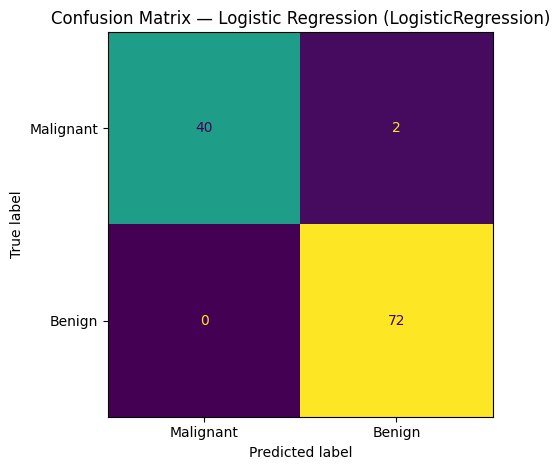

In [ ]:
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr  = lr_model.predict(X_test)

evaluate('Logistic Regression (LogisticRegression)', y_test, y_pred_lr)
batch_acc = accuracy_score(y_test, y_pred_lr)

---

## 4: Three Ways to Walk Downhill

All gradient-based training "walks downhill" on the loss — but *how big each step is* and *how
much data each step looks at* changes how the journey goes. Two classic recipes:

| Optimiser | How each step is taken | Trade-off |
|---|---|---|
| **Batch Gradient Descent** | use **all** training rows for every step | smooth, but each step is expensive |
| **Stochastic Gradient Descent (SGD)** | use **one** row at a time | fast, cheap steps, but noisy |


We train logistic regression with the first two and watch how the loss drops.

In [ ]:
#1) TRUE BATCH gradient descent for logistic regression
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def batch_gradient_descent(X, y, lr=0.5, epochs=50):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for _ in range(epochs):
        p = sigmoid(X @ w + b)        # predictions using ALL rows
        grad = p - y                  # gradient of log-loss wrt z, where z = X@w + b
        w -= lr * (X.T @ grad) / n    # one step using the full batch gradient
        b -= lr * grad.mean()
        p = np.clip(sigmoid(X @ w + b), 1e-9, 1 - 1e-9) # Clipping for numerical stability
        losses.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
    return losses

X_tr_np = X_train.to_numpy(dtype=float)
y_tr    = y_train.astype(float)

n_epochs = 50
batch_loss_per_epoch = batch_gradient_descent(X_tr_np, y_tr, lr=0.5, epochs=n_epochs)

#2) STOCHASTIC gradient descent: one epoch at a time so we can record the loss after each pass
sgd_model = SGDClassifier(loss='log_loss', learning_rate= 'optimal', random_state=42)
n_epochs  = 50
sgd_loss_per_epoch = []

for epoch in range(n_epochs):
    sgd_model.partial_fit(X_train, y_train, classes=np.array([0, 1]))
    proba = sgd_model.predict_proba(X_train)[:, 1]
    sgd_loss_per_epoch.append(log_loss(y_train, proba))




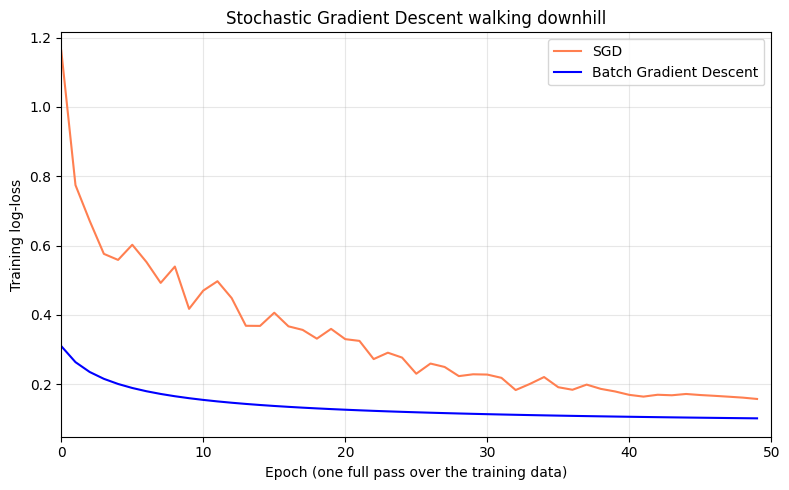

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(range(0, 50), sgd_loss_per_epoch, '-', color='coral', label='SGD')
plt.plot(range(0, 50), batch_loss_per_epoch, '-', color='blue', label='Batch Gradient Descent')

plt.xlabel('Epoch (one full pass over the training data)')
plt.xlim(0, 50)
plt.ylabel('Training log-loss')
plt.title('Stochastic Gradient Descent walking downhill')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Summary

**Polynomial features** let a linear model bend — but more flexibility is a double-edged sword.
On data that is already close to linearly separable (like this one), high-degree models
**overfit**: they ace the training set and stumble on the test set.

**Regularization** is the cure. `Ridge` (L2) shrinks every weight; `Lasso` (L1) goes further and
sets many weights to **exactly zero**, quietly selecting the handful of features that matter.

| Property | Ridge (L2) | Lasso (L1) |
|---|---|---|
| scikit-learn class | `Ridge` | `Lasso` |
| Tuning knob | `alpha` (larger = more penalty) | `alpha` (larger = more penalty) |
| Effect on weights | shrinks all | drives some to exactly 0 |
| Sparsity / feature selection | No | Yes |

**Logistic regression** wraps the linear score in a sigmoid to produce a probability, and is
trained by **gradient descent** on the log-loss. We compared two optimisers — **Batch GD** and
**SGD**, and saw how they converge: batch GD is smooth but
expensive, SGD is cheap but noisy.

---

## Take-home Exercise 1 — Why didn't Polynomial Linear Regression help?

In Step 2 the fancy degree-2 and degree-3 models did **not** beat the plain linear model on the the test set, could you explain why? Also try to find a dataset where Polynomial Linear Regression would give better performance?

*Difficulty Level :  Moderate*

---

## Take-home Exercise 2 — Implement Polynomial Logistic Regression

Step 2 used polynomial features with *linear* regression. Step 3 used logistic regression on the
*plain* features. Now combine the two on the **breast-cancer data**: feed polynomial features into
a **logistic regression** classifier and see whether a curved boundary helps the diagnosis.

Fill in the blanks below, run it, and compare the result with the logistic regression from Step 3.
*(Hint: with 230 features the model can overfit — try the `C` parameter, where a smaller `C` means
stronger regularization, e.g. `C=0.1`.)*

*Difficulty Level - High*

In [ ]:

# fill in the blanks (____) and run, using the breast-cancer data

# Step 1: build degree-2 polynomial features from the training and test sets
poly = PolynomialFeatures(degree=____, include_bias=False)
X_train_poly = poly.____(X_train)
X_test_poly  = poly.____(X_test)
print("Number of features:", X_train_poly.shape[1])

# Step 2: train logistic regression on the polynomial features
poly_logreg = LogisticRegression(max_iter=5000, C=____)
poly_logreg.fit(____, ____)

# Step 3: evaluate with the SAME helper we used everywhere else
y_pred_poly = poly_logreg.predict(____)
evaluate('Polynomial Logistic Regression', y_test, y_pred_poly)

'# fill in the blanks (____) and run, using the breast-cancer data\n\n# Step 1: build degree-2 polynomial features from the training and test sets\npoly = PolynomialFeatures(degree=____, include_bias=False)\nX_train_poly = poly.____(X_train)\nX_test_poly  = poly.____(X_test)\nprint("Number of features:", X_train_poly.shape[1])\n\n# Step 2: train logistic regression on the polynomial features\npoly_logreg = LogisticRegression(max_iter=5000, C=____)\npoly_logreg.fit(____, ____)\n\n# Step 3: evaluate with the SAME helper we used everywhere else\ny_pred_poly = poly_logreg.predict(____)\nevaluate(\'Polynomial Logistic Regression\', y_test, y_pred_poly)'